In [2]:
# Importing necessary libraries
import os
import time
import json
import random
import getpass
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### **PHASE 1. USER CREDENTIAL VALIDATION**

In [3]:
def get_credentials():
    print("\n" + "="*60)
    print("SOCIAL MEDIA ANALYTICS PLATFORM")
    print("="*60)

    platform = input("\nEnter social media platform (Twitter/Instagram/Facebook): ").strip().lower()
    username = getpass.getpass("Enter your username: ").strip()
    email = getpass.getpass("Enter your email: ").strip()
    password = getpass.getpass("Enter your password: ").strip()

    if not platform or not username or not email or not password:
        print("\n❌ Invalid credentials or missing fields.\n")
        return None

    print("\n✅ Credentials validated successfully.\n")
    return {
        'platform': platform,
        'username': username,
        'email': email,
        'password': password
    }

### **PHASE 2. MOCK DATA GENERATION PER PLATFORM**

In [4]:
def mock_user_data(platform, username):
    # Use username+platform as seed to make the output unique
    seed = abs(hash(username + platform)) % 2**32
    np.random.seed(seed)

    if platform == 'twitter':
        return pd.DataFrame({
            'tweet': [f"Tweet {i}" for i in range(100)],
            'likes': np.random.randint(10, 500, 100),
            'retweets': np.random.randint(5, 100, 100),
            'sentiment': np.random.uniform(-1, 1, 100)
        })

    elif platform == 'instagram':
        return pd.DataFrame({
            'post': [f"Photo {i}" for i in range(100)],
            'likes': np.random.randint(100, 2000, 100),
            'comments': np.random.randint(10, 200, 100),
            'sentiment': np.random.uniform(-1, 1, 100)
        })

    elif platform == 'facebook':
        return pd.DataFrame({
            'post': [f"Status {i}" for i in range(100)],
            'reactions': np.random.randint(50, 1000, 100),
            'shares': np.random.randint(5, 150, 100),
            'sentiment': np.random.uniform(-1, 1, 100)
        })

    else:
        print("❌ Unsupported platform entered!")
        exit()

### **PHASE 3. ANALYSIS FUNCTION PER PLATFORM**

In [5]:
def analyze_behavior(data, platform):
    print(f"\n📊 Analyzing {platform.capitalize()} data...\n")

    if platform == 'twitter':
        data['engagement'] = data['likes'] + data['retweets']
    elif platform == 'instagram':
        data['engagement'] = data['likes'] + data['comments']
    elif platform == 'facebook':
        data['engagement'] = data['reactions'] + data['shares']

    data['sentiment_category'] = data['sentiment'].apply(
        lambda x: 'Positive' if x > 0.2 else 'Negative' if x < -0.2 else 'Neutral'
    )

    print("🔍 Engagement & Sentiment Overview:")
    print(data.describe())

    sns.histplot(data['sentiment'], kde=True)
    plt.title(f'{platform.capitalize()} Sentiment Distribution')
    plt.xlabel('Sentiment')
    plt.ylabel('Frequency')
    plt.show()

    sns.lineplot(x=range(len(data)), y=data['engagement'])
    plt.title(f'{platform.capitalize()} Engagement Trend')
    plt.xlabel('Posts')
    plt.ylabel('Engagement')
    plt.show()

    return data

### **PHASE 4. PREDICTION MODEL**

In [6]:
def predict_behavior(data):
    print("🔮 Predicting future engagement trends...")

    series = data['engagement'].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled_series = scaler.fit_transform(series)

    X, y = [], []
    for i in range(10, len(scaled_series)):
        X.append(scaled_series[i-10:i])
        y.append(scaled_series[i])

    X, y = np.array(X), np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test),
              callbacks=[EarlyStopping(patience=3)], verbose=0)

    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)

    plt.plot(scaler.inverse_transform(y_test), label='True Engagement')
    plt.plot(predictions, label='Predicted Engagement')
    plt.legend()
    plt.title('Engagement Prediction')
    plt.xlabel('Time')
    plt.ylabel('Engagement')
    plt.show()


### **PHASE 5. MAIN FUNCTION**

In [7]:
def main():
    credentials = get_credentials()
    if not credentials:
        return

    platform = credentials['platform']
    username = credentials['username']

    data = mock_user_data(platform, username)
    analyzed = analyze_behavior(data, platform)
    predict_behavior(analyzed)


SOCIAL MEDIA ANALYTICS PLATFORM

Enter social media platform (Twitter/Instagram/Facebook): instagram
Enter your username: ··········
Enter your email: ··········
Enter your password: ··········

✅ Credentials validated successfully.


📊 Analyzing Instagram data...

🔍 Engagement & Sentiment Overview:
             likes    comments   sentiment   engagement
count   100.000000  100.000000  100.000000   100.000000
mean   1127.260000  105.030000    0.127043  1232.290000
std     538.787633   58.829741    0.543427   534.634989
min     140.000000   11.000000   -0.944421   186.000000
25%     634.500000   53.500000   -0.276977   704.750000
50%    1205.500000  104.500000    0.164786  1326.500000
75%    1543.250000  158.000000    0.576937  1627.250000
max    1996.000000  199.000000    0.998491  2154.000000


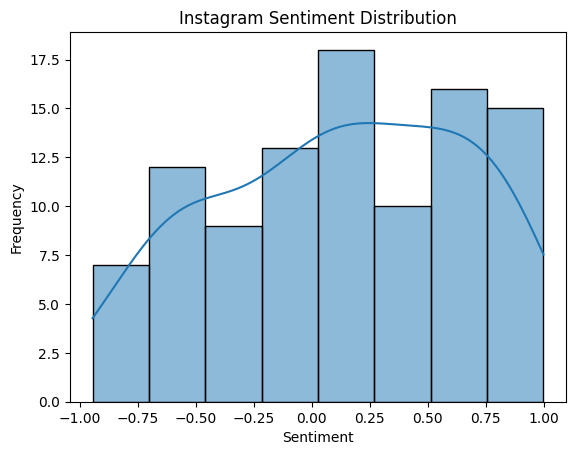

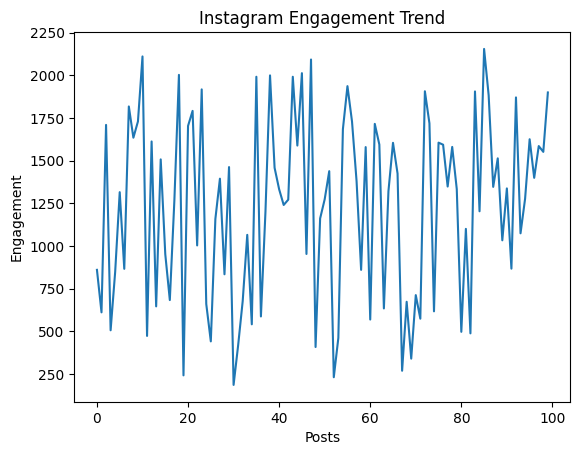

🔮 Predicting future engagement trends...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


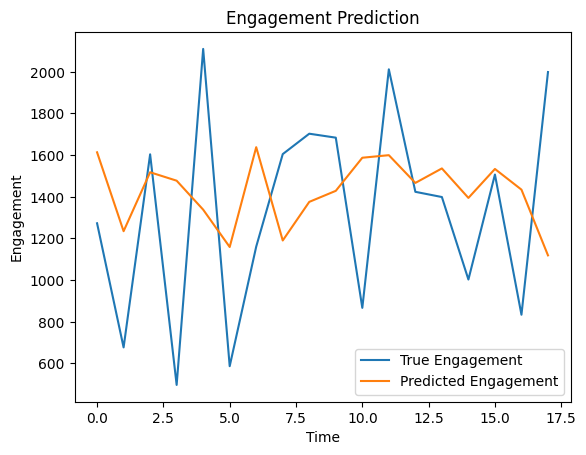

In [9]:
# Run the full pipeline
if __name__ == "__main__":
    main()